In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pandas_datareader as data
from sklearn.preprocessing import MinMaxScaler
from keras.layers import Dense, Dropout, LSTM
from keras.models import Sequential

*1. Define time frame and fetch stock data*

In [11]:
import yfinance as yf

start = '2014-01-01'
end = '2024-12-31'
df = yf.download('AAPL', start=start, end=end, auto_adjust=False)
df.head()

[*********************100%***********************]  1 of 1 completed


Price,Adj Close,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,,
2014-01-02,17.124882,19.754642,19.893929,19.715000,19.845715,234684800
2014-01-03,16.748722,19.320715,19.775000,19.301071,19.745001,392467600
2014-01-06,16.840046,19.426071,19.528570,19.057142,19.194643,412610800
2014-01-07,16.719625,19.287144,19.498571,19.211430,19.440001,317209200
2014-01-08,16.825500,19.409286,19.484285,19.238930,19.243214,258529600


*2. Preprocess Data*

In [12]:
df = df.reset_index()
df = df.drop(['Date', 'Adj Close'], axis=1)

/tmp/ipykernel_8735/1867293422.py:2: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  df = df.drop(['Date', 'Adj Close'], axis=1)


*3. Visualizations*

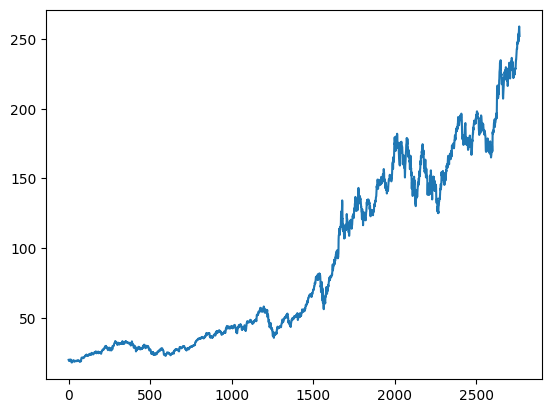

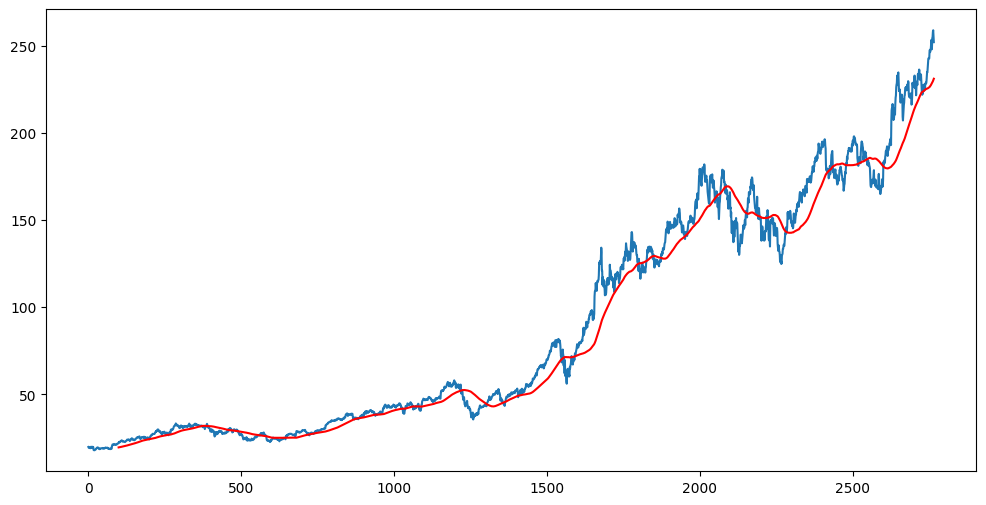

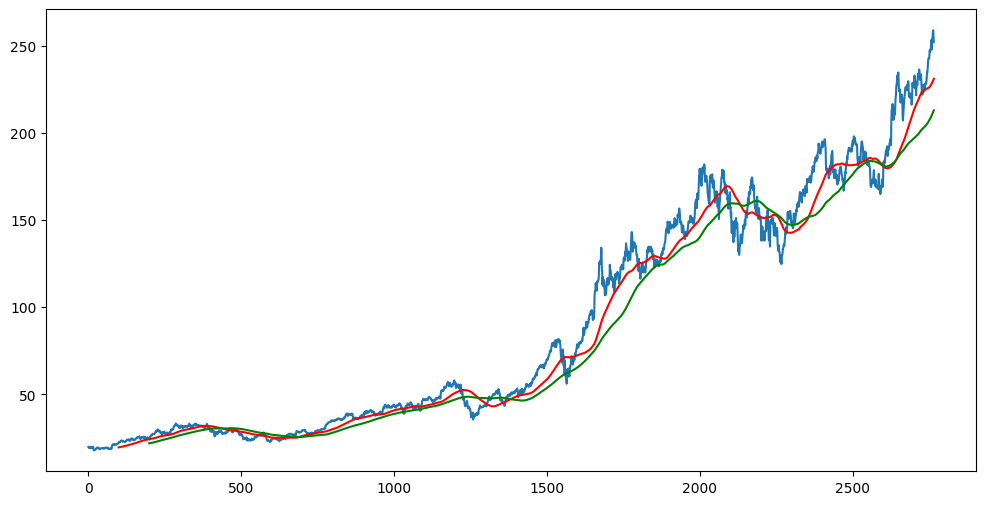

In [13]:
plt.plot(df.Close)

ma100 = df.Close.rolling(100).mean()
plt.figure(figsize=(12,6))
plt.plot(df.Close)
plt.plot(ma100, 'r')

ma200 = df.Close.rolling(200).mean()
plt.figure(figsize=(12,6))
plt.plot(df.Close)
plt.plot(ma100, 'r')
plt.plot(ma200, 'g')

*4. Splitting Data into Training (70%) and Testing (30%)*

In [14]:
data_training = pd.DataFrame(df['Close'][0:int(len(df)*0.70)])
data_testing = pd.DataFrame(df['Close'][int(len(df)*0.70): int(len(df))])

# Scale the training data between 0 and 1
scaler = MinMaxScaler(feature_range=(0,1))
data_training_array = scaler.fit_transform(data_training)

*5. Prepare Training Batches (using a 100-day time step window)*

In [15]:
x_train = []
y_train = []

for i in range(100, data_training_array.shape[0]):
    x_train.append(data_training_array[i-100:i])
    y_train.append(data_training_array[i, 0])

x_train, y_train = np.array(x_train), np.array(y_train)

*6. Build the LSTM Architecture*

In [16]:
model = Sequential()

# Layer 1
model.add(LSTM(units=50, activation='relu', return_sequences=True, input_shape=(x_train.shape[1], 1)))
model.add(Dropout(0.2))

# Layer 2
model.add(LSTM(units=60, activation='relu', return_sequences=True))
model.add(Dropout(0.3))

# Layer 3
model.add(LSTM(units=80, activation='relu', return_sequences=True))
model.add(Dropout(0.4))

# Layer 4
model.add(LSTM(units=120, activation='relu'))
model.add(Dropout(0.5))

# Output Dense Layer
model.add(Dense(units=1))

# Compile and Fit Model
model.compile(optimizer='adam', loss='mean_squared_error')
model.fit(x_train, y_train, epochs=50)

# Save the trained model to disk
model.save('keras_model.h5')

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


58/58 ━━━━━━━━━━━━━━━━━━━━ 17s 121ms/step - loss: 0.0222
Epoch 2/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - loss: 0.0050
Epoch 3/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - loss: 0.0049
Epoch 4/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - loss: 0.0046
Epoch 5/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - loss: 0.0042
Epoch 6/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - loss: 0.0034
Epoch 7/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - loss: 0.0037
Epoch 8/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - loss: 0.0035
Epoch 9/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - loss: 0.0031
Epoch 10/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - loss: 0.0029
Epoch 11/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - loss: 0.0030
Epoch 12/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - loss: 0.0035
Epoch 13/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - loss: 0.0037
Epoch 14/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - loss: 0.0033
Epoch 15/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - loss: 0.0029
Epoch 16/50
5

*7. Testing and Model Performance Evaluation*

26/26 ━━━━━━━━━━━━━━━━━━━━ 3s 57ms/step


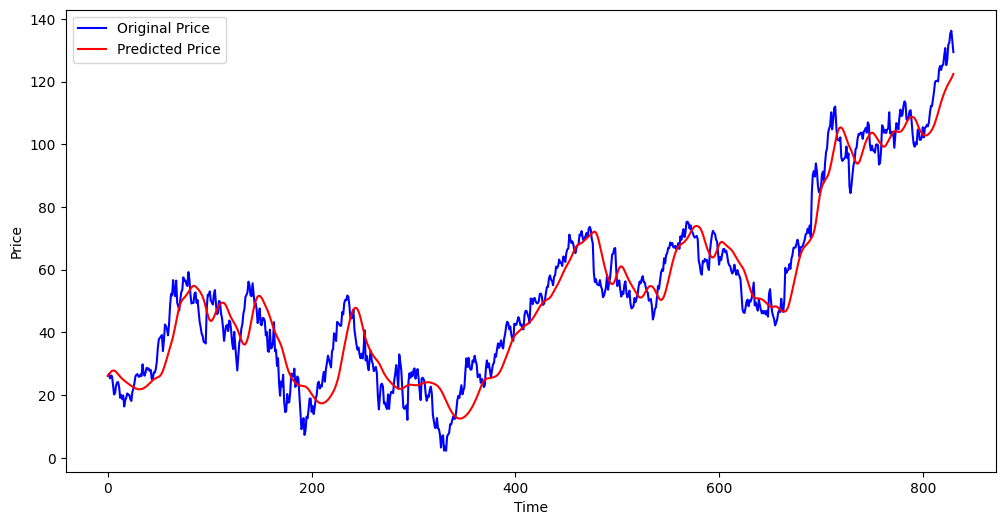

In [17]:
past_100_days = data_training.tail(100)
final_df = pd.concat([past_100_days, data_testing], ignore_index=True)
input_data = scaler.fit_transform(final_df)

x_test = []
y_test = []

for i in range(100, input_data.shape[0]):
    x_test.append(input_data[i-100:i])
    y_test.append(input_data[i, 0])

x_test, y_test = np.array(x_test), np.array(y_test)

# Making Predictions
y_predicted = model.predict(x_test)

# Inverse Scale to get original price formatting
scale_factor = 1 / scaler.scale_[0]
y_predicted = y_predicted * scale_factor
y_test = y_test * scale_factor

# Plotting the Final Comparison Graph
plt.figure(figsize=(12,6))
plt.plot(y_test, 'b', label='Original Price')
plt.plot(y_predicted, 'r', label='Predicted Price')
plt.xlabel('Time')
plt.ylabel('Price')
plt.legend()
plt.show()